# TED Talk Temporal Analysis - BERTopic

In [1]:
import pandas as pd
import kagglehub
from collections import Counter
import ast
import matplotlib.pyplot as plt

/Users/emilydonofrio/NLaoP/gensim-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from gensim import corpora, models
from gensim.models import CoherenceModel
import nltk
import sklearn
import spacy
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [4]:
# %%python -m spacy download en_core_web_sm
nlp_processor = spacy.load("en_core_web_sm")

In [5]:


# Download latest version
path = kagglehub.dataset_download("miguelcorraljr/ted-ultimate-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/emilydonofrio/.cache/kagglehub/datasets/miguelcorraljr/ted-ultimate-dataset/versions/2


In [6]:
data_path = "/2020-05-01/ted_talks_en.csv"

full_path = path + data_path
print(full_path)

/Users/emilydonofrio/.cache/kagglehub/datasets/miguelcorraljr/ted-ultimate-dataset/versions/2/2020-05-01/ted_talks_en.csv


In [7]:


df = pd.read_csv(full_path)
df.shape

(4005, 19)

In [8]:
df.head()

,talk_id,title,speaker_1,all_speakers,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
0,1,Averting the climate crisis,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the world’...,3523392,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,"['alternative energy', 'cars', 'climate change...","{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,With the same humor and humanity he exuded in ...,"Thank you so much, Chris. And it's truly a gre..."
1,92,The best stats you've ever seen,Hans Rosling,{0: 'Hans Rosling'},{0: ['global health expert; data visionary']},"{0: 'In Hans Rosling’s hands, data sings. Glob...",14501685,2006-02-22,2006-06-27,TED2006,en,"['ar', 'az', 'bg', 'bn', 'bs', 'cs', 'da', 'de...",628.0,1190,"['Africa', 'Asia', 'Google', 'demo', 'economic...","{2056: ""Own your body's data"", 2296: 'A visual...",https://www.ted.com/talks/hans_rosling_the_bes...,You've never seen data presented like this. Wi...,"About 10 years ago, I took on the task to teac..."
2,7,Simplicity sells,David Pogue,{0: 'David Pogue'},{0: ['technology columnist']},{0: 'David Pogue is the personal technology co...,1920832,2006-02-24,2006-06-27,TED2006,en,"['ar', 'bg', 'de', 'el', 'en', 'es', 'fa', 'fr...",124.0,1286,"['computers', 'entertainment', 'interface desi...","{1725: '10 top time-saving tech tips', 2274: '...",https://www.ted.com/talks/david_pogue_simplici...,New York Times columnist David Pogue takes aim...,"(Music: ""The Sound of Silence,"" Simon & Garfun..."
3,53,Greening the ghetto,Majora Carter,{0: 'Majora Carter'},{0: ['activist for environmental justice']},{0: 'Majora Carter redefined the field of envi...,2664069,2006-02-26,2006-06-27,TED2006,en,"['ar', 'bg', 'bn', 'ca', 'cs', 'de', 'en', 'es...",219.0,1116,"['MacArthur grant', 'activism', 'business', 'c...",{1041: '3 stories of local eco-entrepreneurshi...,https://www.ted.com/talks/majora_carter_greeni...,"In an emotionally charged talk, MacArthur-winn...",If you're here today — and I'm very happy that...
4,66,Do schools kill creativity?,Sir Ken Robinson,{0: 'Sir Ken Robinson'},"{0: ['author', 'educator']}","{0: ""Creativity expert Sir Ken Robinson challe...",65051954,2006-02-25,2006-06-27,TED2006,en,"['af', 'ar', 'az', 'be', 'bg', 'bn', 'ca', 'cs...",4931.0,1164,"['children', 'creativity', 'culture', 'dance',...","{865: 'Bring on the learning revolution!', 173...",https://www.ted.com/talks/sir_ken_robinson_do_...,Sir Ken Robinson makes an entertaining and pro...,Good morning. How are you? (Audience) Good. It...


## Preprocessing

In [9]:
df['recorded_date'] = pd.to_datetime(df['recorded_date'])
df['recorded_date'].max()

Timestamp('2020-04-30 00:00:00')

In [10]:
df['Year'] = df['recorded_date'].dt.year

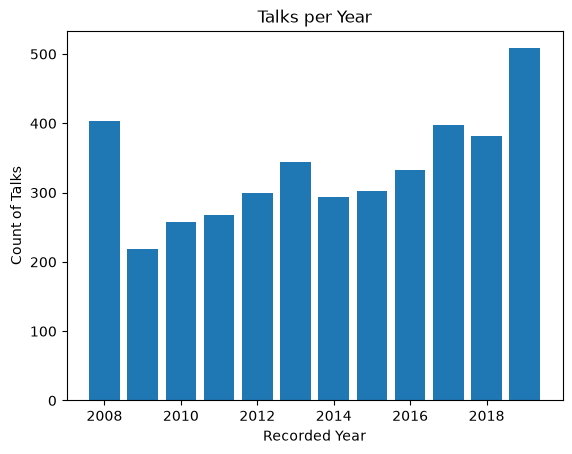

In [11]:
# create year groups
def yeargroup(year):
  if year < 2008:
    return 2008
  if year == 2020:
    return 2019
  return year

df['year_group'] = df['Year'].apply(yeargroup)

# plot count of talks per year
talk_count = df.groupby("year_group")['talk_id'].size().reset_index()

plt.bar(x="year_group", height='talk_id', data=talk_count)
plt.title("Talks per Year")
plt.ylabel("Count of Talks")
plt.xlabel("Recorded Year")
plt.show()

In [20]:
import re

# remove stopwords
custom_speaking_stopwords = [
    "people",
    "like",
    "know",
    "think",
    "really",
    "going",
    "one",
    "would",
    "say",
    "see",
    "got",
    "get",
    "thing",
    "things",
    "that",
    "it"
]
stopwords = set(nltk.corpus.stopwords.words('english') + custom_speaking_stopwords)

transcripts = df["transcript"].str.lower()

clean_transcripts = []

for doc in transcripts:
    # keep only letters and spaces
    doc = re.sub(r"[^a-z\s]", " ", doc)

    words = [
        w
        for w in doc.split()
        if w not in stopwords
    ]

    clean_transcripts.append(" ".join(words))
    
# don't tokenize transcripts, as BERTopic will handle that internally

# BERTopic

In [21]:
len(clean_transcripts)

4005

In [22]:
clean_transcripts[0]

'thank much chris truly great honor opportunity come stage twice extremely grateful blown away conference want thank many nice comments night sincerely partly mock sob need laughter put position laughter flew air force two eight years laughter take shoes boots airplane laughter applause tell quick story illustrate laughter true story every bit true soon tipper left mock sob white house laughter driving home nashville little farm miles east nashville driving laughter sounds little laughter looked rear view mirror sudden hit motorcade back laughter heard phantom limb pain laughter rented ford taurus laughter dinnertime started looking place eat exit lebanon tennessee exit found shoney restaurant low cost family restaurant chain went sat booth waitress came made big commotion tipper laughter took order went couple booth next us lowered voice much strain hear saying said yes former vice president al gore wife tipper man said come long way laughter applause kind series epiphanies laughter n

In [63]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)



vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=10,
    max_df=0.8,
    ngram_range=(1,2)
)

BERT_model1 = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=20,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = BERT_model1.fit_transform(clean_transcripts)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8075.92it/s]
2026-08-02 15:44:56,703 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 126/126 [00:10<00:00, 11.92it/s]
2026-08-02 15:45:07,295 - BERTopic - Embedding - Completed ✓
2026-08-02 15:45:07,295 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-02 15:45:15,421 - BERTopic - Dimensionality - Completed ✓
2026-08-02 15:45:15,421 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-02 15:45:15,591 - BERTopic - Cluster - Completed ✓
2026-08-02 15:45:15,593 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-02 15:45:18,170 - BERTopic - Representation - Completed ✓


In [64]:
BERT_model1.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1883,-1_girls_ca_hiv_babies,"[girls, ca, hiv, babies, drugs, treatment, inc...",[given slide show gave two years ago times giv...
1,0,175,0_stars_planets_mars_quantum,"[stars, planets, mars, quantum, particles, tel...",[tell real search alien life little green huma...
2,1,152,1_musical_la_singing_piano,"[musical, la, singing, piano, musicians, instr...",[music music brain makes sounds noise context ...
3,2,141,2_neurons_cells_consciousness_cortex,"[neurons, cells, consciousness, cortex, electr...",[want tell guys something neuroscience physici...
4,3,126,3_cells_cancer_bacteria_genome,"[cells, cancer, bacteria, genome, virus, immun...",[decades research billions dollars spent clini...
5,4,113,4_nuclear_solar_carbon_emissions,"[nuclear, solar, carbon, emissions, climate ch...",[america public energy conversation boils ques...
6,5,96,5_robot_ai_artificial_algorithm,"[robot, ai, artificial, algorithm, interface, ...",[today talk ai us ai researchers always said h...
7,6,94,6_fishing_marine_oceans_shark,"[fishing, marine, oceans, shark, reef, seas, u...",[share morning stories ocean work still photog...
8,7,90,7_patients_patient_surgery_cancer,"[patients, patient, surgery, cancer, breast, h...",[five years ago sabbatical returned medical un...
9,8,89,8_afghanistan_iran_arab_arabic,"[afghanistan, iran, arab, arabic, iraq, israel...",[iran israel best friend intend change positio...


In [65]:
new_topics = BERT_model1.reduce_outliers(
    clean_transcripts,
    topics,
    strategy="embeddings"
)

BERT_model1.update_topics(
    clean_transcripts,
    topics=new_topics
)

BERT_model1.topics_ = new_topics

2026-08-02 15:45:24,398 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [66]:
BERT_model1.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,219,0_universe_earth_space_light,"[universe, earth, space, light, planet, stars,...",[tell real search alien life little green huma...
1,1,187,1_music_applause_sound_laughter,"[music, applause, sound, laughter, play, song,...",[music music brain makes sounds noise context ...
2,2,187,2_brain_neurons_sleep_cells,"[brain, neurons, sleep, cells, right, brains, ...",[want tell guys something neuroscience physici...
3,3,187,3_cells_cancer_dna_cell,"[cells, cancer, dna, cell, disease, bacteria, ...",[decades research billions dollars spent clini...
4,4,182,4_energy_climate_world_need,"[energy, climate, world, need, nuclear, us, ca...",[america public energy conversation boils ques...
5,5,188,5_computer_technology_actually_robot,"[computer, technology, actually, robot, human,...",[today talk ai us ai researchers always said h...
6,6,123,6_ocean_fish_sea_water,"[ocean, fish, sea, water, sharks, coral, anima...",[share morning stories ocean work still photog...
7,7,174,7_health_patients_care_heart,"[health, patients, care, heart, patient, medic...",[five years ago sabbatical returned medical un...
8,8,205,8_women_war_world_us,"[women, war, world, us, said, many, years, cou...",[iran israel best friend intend change positio...
9,9,148,9_city_building_cities_new,"[city, building, cities, new, design, architec...",[today speak last years architectural history ...


In [67]:
BERT_model1.visualize_topics()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0, 'universe | earth | space | light | planet', 219],
                                   [1, 'music | applause | sound | laughter | play', 187],
                                   [2, 'brain | neurons | sleep | cells | right', 187],
                                   [3, 'cells | cancer | dna | cell | disease', 187],
                                   [4, 'energy | climate | world | need | nuclear', 182],
                                   [5, 'computer | technology | actually | robot | human', 188],
                                   [6, 'ocean | fish | sea | water | sharks', 123],
                                   [7, 'health | patients | care | heart | patient', 174],
                                   [8, 'women | war | world | us | said', 205],
                                   [9, 'city | building | cities | new | design', 148],
                                   [10, 'africa | african | country | world | us', 141],
                                   [11, 'world | china | economic | percent | countries', 150],
                                   [12, 'laughter | women | said | us | time', 223],
                                   [13, 'love | life | feel | us | time', 146],
                                   [14, 'art | something | way | time | laughter', 220],
                                   [15, 'plants | bees | plant | insects | ants', 92],
                                   [16, 'number | mathematics | two | numbers | math', 81],
                                   [17, 'work | time | laughter | us | company', 166],
                                   [18, 'kids | school | students | children | education', 105],
                                   [19, 'king | ancient | power | years | century', 86],
                                   [20, 'laughter | biscuit | said | right | want', 131],
                                   [21, 'laughter | ca | go | world | right', 96],
                                   [22, 'black | us | white | women | rights', 75],
                                   [23, 'us | democracy | government | power | world', 84],
                                   [24, 'prison | police | justice | criminal | drug', 74],
                                   [25, 'water | river | cities | climate | world', 55],
                                   [26, 'male | female | sex | males | sperm', 46],
                                   [27, 'compassion | god | world | us | religion', 67],
                                   [28, 'language | english | languages | words | spelling', 32],
                                   [29, 'animals | dinosaurs | birds | species | animal', 54],
                                   [30, 'internet | data | information | us | actually', 81]], dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
                         'size': {'bdata': ('2wC7ALsAuwC2ALwAewCuAM0AlACNAJ' ... 'MAYABLAFQASgA3AC4AQwAgADYAUQA='),
                                  'dtype': 'i2'},
                         'sizemode': 'area',
                         'sizeref': 0.139375,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': ('sruCP0MpsEBiDIQ+BgiqQKqeRkCdm7' ... 'HkG+A/+U+ZwMz4pD/0H18/LK2twA=='),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('wB0BQVjY7UC1GBpBOPPkQJlqJkFlm/' ... 'CoR/pAwaV+Qa2jIkETB/ZArVyCQQ=='),
                    'dtype': 'f4'},
              'yaxis': 'y'}],
    'layout': {'annotations': [{'showarrow': False,
                                'text': 'D1',
                                'x': np.float32(-6.4

In [68]:
BERT_model1.visualize_barchart()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': '#D55E00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.013664222317144679, 0.016145204395658686,
                    0.018594464650043073, 0.021718047245725895,
                    0.024333065436765337],
              'xaxis': 'x',
              'y': [planet  , light  , space  , earth  , universe  ],
              'yaxis': 'y'},
             {'marker': {'color': '#0072B2'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.01105923897030202, 0.013653786307390899,
                    0.016138658471027006, 0.016646059599871612,
                    0.06022429005541511],
              'xaxis': 'x2',
              'y': [play  , laughter  , sound  , applause  , music  ],
              'yaxis': 'y2'},
             {'marker': {'color': '#CC79A7'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.010404618258801925, 0.010717947696259368,
                    0.014553848466321262, 0.01482934016296478, 0.05214327183892827],
              'xaxis': 'x3',
              'y': [right  , cells  , sleep  , neurons  , brain  ],
              'yaxis': 'y3'},
             {'marker': {'color': '#E69F00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.014257196758107006, 0.01534336122693165,
                    0.017998332581996557, 0.02548635316998964, 0.03036664648013826],
              'xaxis': 'x4',
              'y': [disease  , cell  , dna  , cancer  , cells  ],
              'yaxis': 'y4'},
             {'marker': {'color': '#56B4E9'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.011760654711379031, 0.011762159007529121,
                    0.012499323096210133, 0.01276744019664928,
                    0.014908507353133068],
              'xaxis': 'x5',
              'y': [human  , robot  , actually  , technology  , computer  ],
              'yaxis': 'y5'},
             {'marker': {'color': '#009E73'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.009698973268911946, 0.011091079343507126,
                    0.012145291468082473, 0.014524690847166165,
                    0.01527003062559768],
              'xaxis': 'x6',
              'y': [said  , us  , world  , war  , women  ],
              'yaxis': 'y6'},
             {'marker': {'color': '#F0E442'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.010347802556186194, 0.010648879173248579,
                    0.014358014550563037, 0.01559397706298272,
                    0.016447739930776722],
              'xaxis': 'x7',
              'y': [time  , us  , said  , women  , laughter  ],
              'yaxis': 'y7'},
             {'marker': {'color': '#D55E00'},
              'orientation': 'h',
              'type': 'bar',
              'x': [0.010835533270901917, 0.011214651727128913,
                    0.011367308895660653, 0.011865902913361778,
                    0.01240969452166017],
              'xaxis': 'x8',
              'y': [laughter  , time  , way  , something  , art  ],
              'yaxis': 'y8'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 0',
                                'x': 0.0875,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Topic 1',
                                'x': 0.36250000000000004,
                                'xanchor': 'center',
                                'xref': 'paper',
                     

### Coherence of BERTopic for comparison to LDA

In [69]:
from gensim.corpora import Dictionary

tokenized_docs = [doc.split() for doc in transcripts]

dictionary = Dictionary(tokenized_docs)


In [70]:
topics = BERT_model1.get_topics()

topic_words = []

for topic_id in sorted(topics.keys()):
    if topic_id == -1:
        continue

    words = [word for word, _ in topics[topic_id]]
    topic_words.append(words)

In [71]:
for i, topic in enumerate(topic_words):
    print(i, len(topic), topic[:5])

0 10 ['universe', 'earth', 'space', 'light', 'planet']
1 10 ['music', 'applause', 'sound', 'laughter', 'play']
2 10 ['brain', 'neurons', 'sleep', 'cells', 'right']
3 10 ['cells', 'cancer', 'dna', 'cell', 'disease']
4 10 ['energy', 'climate', 'world', 'need', 'nuclear']
5 10 ['computer', 'technology', 'actually', 'robot', 'human']
6 10 ['ocean', 'fish', 'sea', 'water', 'sharks']
7 10 ['health', 'patients', 'care', 'heart', 'patient']
8 10 ['women', 'war', 'world', 'us', 'said']
9 10 ['city', 'building', 'cities', 'new', 'design']
10 10 ['africa', 'african', 'country', 'world', 'us']
11 10 ['world', 'china', 'economic', 'percent', 'countries']
12 10 ['laughter', 'women', 'said', 'us', 'time']
13 10 ['love', 'life', 'feel', 'us', 'time']
14 10 ['art', 'something', 'way', 'time', 'laughter']
15 10 ['plants', 'bees', 'plant', 'insects', 'ants']
16 10 ['number', 'mathematics', 'two', 'numbers', 'math']
17 10 ['work', 'time', 'laughter', 'us', 'company']
18 10 ['kids', 'school', 'students', '

In [72]:
cm = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v"
)

overall_coherence = cm.get_coherence()

print("Overall coherence:", overall_coherence)

Overall coherence: 0.484862751023138


In [73]:
topic_scores = cm.get_coherence_per_topic()

for i, score in enumerate(topic_scores):
    print(f"Topic {i}: {score:.3f}")

Topic 0: 0.642
Topic 1: 0.410
Topic 2: 0.506
Topic 3: 0.601
Topic 4: 0.475
Topic 5: 0.412
Topic 6: 0.817
Topic 7: 0.625
Topic 8: 0.403
Topic 9: 0.560
Topic 10: 0.425
Topic 11: 0.474
Topic 12: 0.356
Topic 13: 0.362
Topic 14: 0.302
Topic 15: 0.701
Topic 16: 0.431
Topic 17: 0.328
Topic 18: 0.505
Topic 19: 0.440
Topic 20: 0.321
Topic 21: 0.376
Topic 22: 0.468
Topic 23: 0.545
Topic 24: 0.571
Topic 25: 0.434
Topic 26: 0.663
Topic 27: 0.450
Topic 28: 0.664
Topic 29: 0.455
Topic 30: 0.307


## Temporal Heat Maps

In [74]:
topic_info = (
    BERT_model1.get_topic_info()
    .query("Topic != -1")
    .sort_values("Topic")
)

topic_names = [
    f"Topic_{row.Topic}: {', '.join(BERT_model1.get_topic(row.Topic)[:5][i][0] for i in range(5))}"
    for _, row in topic_info.iterrows()
]

print(len(topic_names))
print(probs.shape[1])

31
31


In [75]:
topic_df = pd.DataFrame(probs, columns=topic_names)
topic_df.head()

,"Topic_0: universe, earth, space, light, planet","Topic_1: music, applause, sound, laughter, play","Topic_2: brain, neurons, sleep, cells, right","Topic_3: cells, cancer, dna, cell, disease","Topic_4: energy, climate, world, need, nuclear","Topic_5: computer, technology, actually, robot, human","Topic_6: ocean, fish, sea, water, sharks","Topic_7: health, patients, care, heart, patient","Topic_8: women, war, world, us, said","Topic_9: city, building, cities, new, design",...,"Topic_21: laughter, ca, go, world, right","Topic_22: black, us, white, women, rights","Topic_23: us, democracy, government, power, world","Topic_24: prison, police, justice, criminal, drug","Topic_25: water, river, cities, climate, world","Topic_26: male, female, sex, males, sperm","Topic_27: compassion, god, world, us, religion","Topic_28: language, english, languages, words, spelling","Topic_29: animals, dinosaurs, birds, species, animal","Topic_30: internet, data, information, us, actually"
0,6.614344e-03,2.487561e-02,7.980978e-03,6.677219e-03,6.889195e-03,1.222918e-02,5.765252e-03,8.309942e-03,1.057119e-02,1.088347e-02,...,4.767873e-01,1.400327e-02,1.097918e-02,1.548376e-02,7.512082e-03,6.351306e-03,1.466326e-02,1.927494e-02,6.195504e-03,1.996756e-02
1,7.788427e-03,7.262195e-03,8.077924e-03,9.223624e-03,1.452341e-02,1.129542e-02,8.292382e-03,1.130463e-02,2.036361e-02,1.757210e-02,...,1.018355e-02,1.588331e-02,2.759873e-02,1.305199e-02,1.755783e-02,8.780401e-03,1.671555e-02,9.795203e-03,9.278916e-03,1.799075e-02
2,3.771205e-308,1.172509e-307,4.987213e-308,3.974026e-308,3.846779e-308,7.854271e-308,3.267421e-308,5.041254e-308,5.531293e-308,6.115435e-308,...,2.576826e-307,6.743547e-308,5.782157e-308,7.179284e-308,4.219880e-308,3.749623e-308,8.640357e-308,1.180014e-307,3.581828e-308,1.391344e-307
3,4.890473e-308,3.742236e-308,3.921005e-308,3.971498e-308,9.656088e-308,7.035947e-308,5.413102e-308,4.236767e-308,5.655136e-308,1.000000e+00,...,5.084549e-308,5.331717e-308,7.181766e-308,4.802859e-308,1.411903e-307,4.592676e-308,6.003422e-308,5.542281e-308,5.669720e-308,9.369368e-308
4,8.657430e-03,1.911490e-02,1.108760e-02,9.945698e-03,1.018859e-02,1.736625e-02,8.149241e-03,1.287812e-02,1.537016e-02,1.654299e-02,...,4.169864e-02,2.289448e-02,1.665977e-02,2.524268e-02,1.155619e-02,9.137764e-03,2.156153e-02,1.873436e-02,8.921558e-03,3.163132e-02


In [76]:
topic_df["year_group"] = df["year_group"].values

In [79]:
topic_year = topic_df.groupby("year_group").mean()
topic_year.sort_index()

,"Topic_0: universe, earth, space, light, planet","Topic_1: music, applause, sound, laughter, play","Topic_2: brain, neurons, sleep, cells, right","Topic_3: cells, cancer, dna, cell, disease","Topic_4: energy, climate, world, need, nuclear","Topic_5: computer, technology, actually, robot, human","Topic_6: ocean, fish, sea, water, sharks","Topic_7: health, patients, care, heart, patient","Topic_8: women, war, world, us, said","Topic_9: city, building, cities, new, design",...,"Topic_21: laughter, ca, go, world, right","Topic_22: black, us, white, women, rights","Topic_23: us, democracy, government, power, world","Topic_24: prison, police, justice, criminal, drug","Topic_25: water, river, cities, climate, world","Topic_26: male, female, sex, males, sperm","Topic_27: compassion, god, world, us, religion","Topic_28: language, english, languages, words, spelling","Topic_29: animals, dinosaurs, birds, species, animal","Topic_30: internet, data, information, us, actually"
year_group,,,,,,,,,,,,,,,,,,,,,
2008.0,0.023881,0.044747,0.020293,0.011379,0.020416,0.031608,0.017118,0.013210,0.013745,0.026382,...,0.037963,0.011771,0.013731,0.011042,0.015690,0.013209,0.025321,0.016402,0.020992,0.025442
2009.0,0.014451,0.023432,0.029953,0.019034,0.023166,0.024396,0.015097,0.020704,0.022091,0.025536,...,0.030794,0.013962,0.023731,0.011953,0.027513,0.014074,0.040637,0.012797,0.018475,0.024462
2010.0,0.012210,0.034912,0.015107,0.016530,0.022373,0.023138,0.039936,0.018262,0.024472,0.023652,...,0.022404,0.014612,0.027733,0.012339,0.017979,0.015469,0.028197,0.012191,0.019364,0.020971
2011.0,0.020043,0.049883,0.033057,0.021350,0.017887,0.017267,0.014487,0.039089,0.032541,0.025648,...,0.028202,0.014339,0.019082,0.013711,0.014391,0.013661,0.020528,0.013762,0.013022,0.033424
2012.0,0.025444,0.026324,0.019097,0.023028,0.024173,0.022442,0.016052,0.028302,0.032385,0.024107,...,0.014902,0.013092,0.024885,0.017943,0.016524,0.017385,0.015283,0.020586,0.014308,0.030095
2013.0,0.023494,0.020157,0.026868,0.016876,0.012566,0.024282,0.020597,0.026112,0.024754,0.035361,...,0.015068,0.012018,0.025676,0.017961,0.015611,0.015854,0.013537,0.020685,0.025712,0.031015
2014.0,0.017703,0.027546,0.029330,0.020966,0.015239,0.021179,0.014867,0.025006,0.031283,0.035076,...,0.015115,0.020398,0.023575,0.022971,0.018299,0.023015,0.020432,0.018442,0.013930,0.023948
2015.0,0.023660,0.023969,0.021896,0.018836,0.015900,0.022556,0.023131,0.015418,0.024707,0.017181,...,0.014486,0.016614,0.016111,0.020285,0.018784,0.022953,0.022507,0.023144,0.015638,0.024257
2016.0,0.020184,0.025596,0.013373,0.017385,0.019919,0.024417,0.012434,0.020049,0.028513,0.022644,...,0.026713,0.036592,0.025380,0.028107,0.018159,0.015795,0.015924,0.025353,0.017128,0.022396


<Axes: xlabel='year_group'>

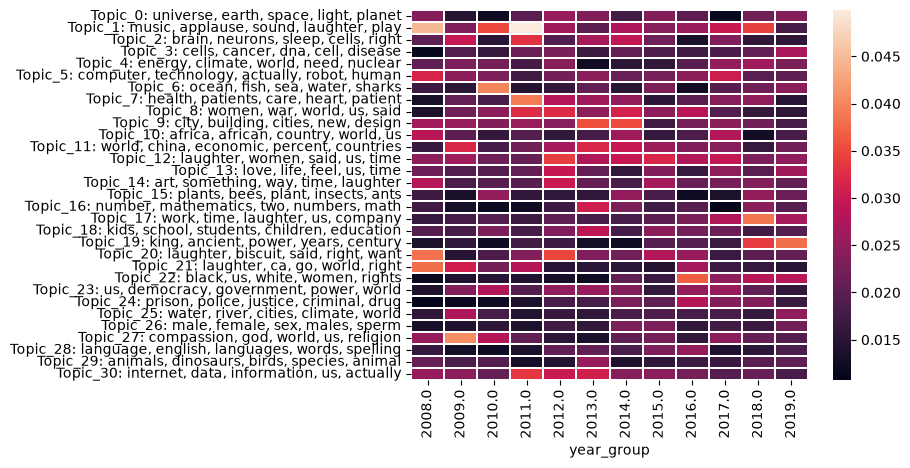

In [80]:
import seaborn as sns

sns.heatmap(
    topic_year.T,
    linewidths=.2,
    xticklabels=True,
    yticklabels=True
)

<Axes: xlabel='year_group'>

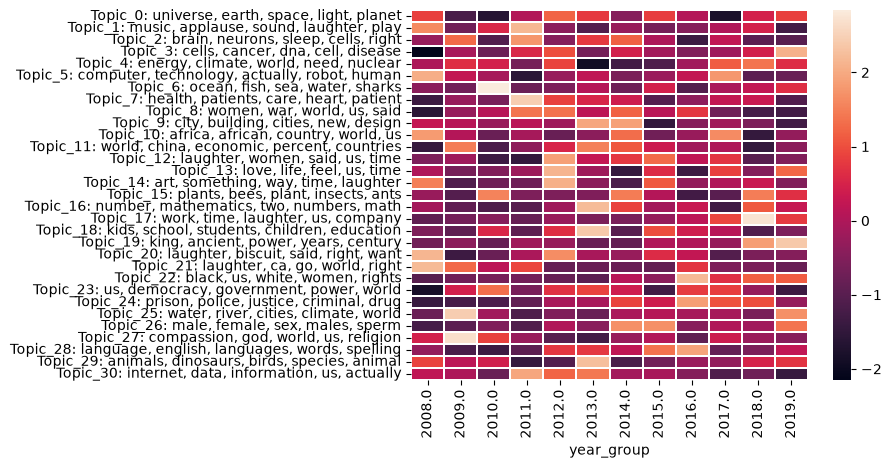

In [81]:
# z-score heatmap
from scipy.stats import zscore

heatmap_data = topic_year.apply(zscore)
sns.heatmap(
    heatmap_data.T,
    linewidths=.2,
    xticklabels=True,
    yticklabels=True
)